# Hotel Customer Value Classification
**Group 6 — Project Update 1 (Dataset 2)**  
Lydia Su · Noah Yin · Xiaoheng Song · Yunpei Wang · Zekai Li

---
**Reference paper:**  
António, N., de Almeida, A., & Nunes, L. (2020). *A hotel's customers personal, behavioral, demographic, and geographic dataset from Lisbon, Portugal (2015–2018).* Data in Brief, 33, 106583.

**Dataset:**  
Hotel Customers Dataset — 83,590 customer records with 31 variables from a 4-star city hotel in Lisbon, Portugal (2015–2018).

**Objective:**  
Classify hotel customers as **high-value** or **low-value** based on lodging revenue. This complements the booking-level cancellation prediction (Dataset 1) by identifying *which customers matter most* — enabling hotels to prioritize retention efforts on high-value customers at risk of cancellation.

---
## Notebook outline
| # | Section | Checklist item covered |
|---|---------|------------------------|
| 1 | Setup & data loading | — |
| 2 | Data cleaning & filtering | Best practices: handling missing values, outliers |
| 3 | EDA | Business context, class balance |
| 4 | Feature engineering | Best practices: leakage prevention |
| 5 | Data splitting | Best practices: stratified 80/20 |
| 6 | Model training | ≥1 ML model trained |
| 7 | Evaluation & metrics | Metrics identified, justified, reported |
| 8 | Cross-validation | Best practices: 5-fold stratified CV |
| 9 | Feature importance | Business interpretation |
| 10 | Final summary & saved assets | Code organisation & reproducibility |


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import OneHotEncoder, StandardScaler
from sklearn.impute             import SimpleImputer
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics            import (accuracy_score, precision_score, recall_score,
                                        f1_score, roc_auc_score, confusion_matrix,
                                        ConfusionMatrixDisplay, classification_report, roc_curve)
from sklearn.dummy              import DummyClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from xgboost                    import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
print('All imports successful.')


All imports successful.


In [2]:
# Load dataset
# ── Update the path below to match your environment ──
df_raw = pd.read_excel('HotelCustomersDataset.xlsx')

print(f'Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'\nColumn list:')
for i, col in enumerate(df_raw.columns, 1):
    print(f'  {i:2d}. {col} ({df_raw[col].dtype})')


Loaded 83,590 rows × 31 columns

Column list:
   1. ID (int64)
   2. Nationality (object)
   3. Age (float64)
   4. DaysSinceCreation (int64)
   5. NameHash (object)
   6. DocIDHash (object)
   7. AverageLeadTime (int64)
   8. LodgingRevenue (float64)
   9. OtherRevenue (float64)
  10. BookingsCanceled (int64)
  11. BookingsNoShowed (int64)
  12. BookingsCheckedIn (int64)
  13. PersonsNights (int64)
  14. RoomNights (int64)
  15. DaysSinceLastStay (int64)
  16. DaysSinceFirstStay (int64)
  17. DistributionChannel (object)
  18. MarketSegment (object)
  19. SRHighFloor (int64)
  20. SRLowFloor (int64)
  21. SRAccessibleRoom (int64)
  22. SRMediumFloor (int64)
  23. SRBathtub (int64)
  24. SRShower (int64)
  25. SRCrib (int64)
  26. SRKingSizeBed (int64)
  27. SRTwinBed (int64)
  28. SRNearElevator (int64)
  29. SRAwayFromElevator (int64)
  30. SRNoAlcoholInMiniBar (int64)
  31. SRQuietRoom (int64)


## 2. Data Cleaning & Filtering

### Key decisions:
1. **Filter to active customers only**: 19,919 customer profiles have zero booking activity (no check-ins, no cancellations, no no-shows). These are empty PMS profiles — the paper notes that hotels sometimes create profiles without actual stays. We exclude these.
2. **Handle missing values**: Age has 3,779 missing values (~4.5%). We impute with median.
3. **Remove invalid ages**: The dataset contains ages like -11 and 122, which are data entry errors.
4. **Remove hash columns**: `NameHash` and `DocIDHash` are anonymization artifacts, not predictive features.
5. **Remove `ID`**: Sequential identifier with no predictive value.


In [3]:
df = df_raw.copy()

# ── Step 1: Filter to customers with at least one check-in ──
# Customers with BookingsCheckedIn = 0 have no stay history and no lodging revenue
before = len(df)
df = df[df['BookingsCheckedIn'] > 0].copy()
print(f'Filtered to customers with ≥1 check-in: {before:,} → {len(df):,} (removed {before - len(df):,} inactive profiles)')

# ── Step 2: Drop non-predictive columns ──
DROP_COLS = ['ID', 'NameHash', 'DocIDHash']
df.drop(columns=DROP_COLS, inplace=True)
print(f'Dropped: {DROP_COLS}')

# ── Step 3: Handle missing & invalid Age ──
print(f'\nAge missing values: {df["Age"].isnull().sum()} ({df["Age"].isnull().mean():.2%})')
# Cap age to reasonable range [18, 100], set outliers to NaN, then impute
df.loc[df['Age'] < 18, 'Age'] = np.nan
df.loc[df['Age'] > 100, 'Age'] = np.nan
print(f'Age values outside [18, 100] set to NaN: {df["Age"].isnull().sum()} total NaN')
df['Age'].fillna(df['Age'].median(), inplace=True)
print(f'Age imputed with median ({df["Age"].median():.0f}). Missing after: {df["Age"].isnull().sum()}')

# ── Step 4: Verify no remaining missing values ──
remaining_missing = df.isnull().sum().sum()
print(f'\nTotal missing values after cleaning: {remaining_missing}')
print(f'Final dataset shape: {df.shape}')


Filtered to customers with ≥1 check-in: 83,590 → 63,670 (removed 19,920 inactive profiles)
Dropped: ['ID', 'NameHash', 'DocIDHash']

Age missing values: 2930 (4.60%)
Age values outside [18, 100] set to NaN: 3889 total NaN
Age imputed with median (48). Missing after: 0

Total missing values after cleaning: 0
Final dataset shape: (63670, 28)


## 3. Exploratory Data Analysis

### Target variable construction

We define **customer value** based on `LodgingRevenue`:
- **High-value** (1): LodgingRevenue > median → customers whose lodging spending exceeds the typical customer
- **Low-value** (0): LodgingRevenue ≤ median

**Business justification**: Hotels benefit most from retaining and protecting revenue from high-spending customers. When combined with the booking-level cancellation model (Dataset 1), this enables a **priority matrix**: high-value customers predicted to cancel should receive the most immediate and resource-intensive retention efforts (e.g., personal outreach, room upgrades, flexible rebooking).


In [4]:
# ── Create target variable ──
revenue_median = df['LodgingRevenue'].median()
df['is_high_value'] = (df['LodgingRevenue'] > revenue_median).astype(int)

print('='*55)
print('TARGET VARIABLE: is_high_value')
print('='*55)
print(f'Revenue median (threshold): €{revenue_median:.2f}')
print(f'High-value (1): {df["is_high_value"].sum():,} ({df["is_high_value"].mean():.2%})')
print(f'Low-value  (0): {(1 - df["is_high_value"]).sum():,} ({1 - df["is_high_value"].mean():.2%})')
print(f'\nClass balance is near 50/50 — no resampling needed.')


TARGET VARIABLE: is_high_value
Revenue median (threshold): €302.27
High-value (1): 31,835 (50.00%)
Low-value  (0): 31,835 (50.00%)

Class balance is near 50/50 — no resampling needed.


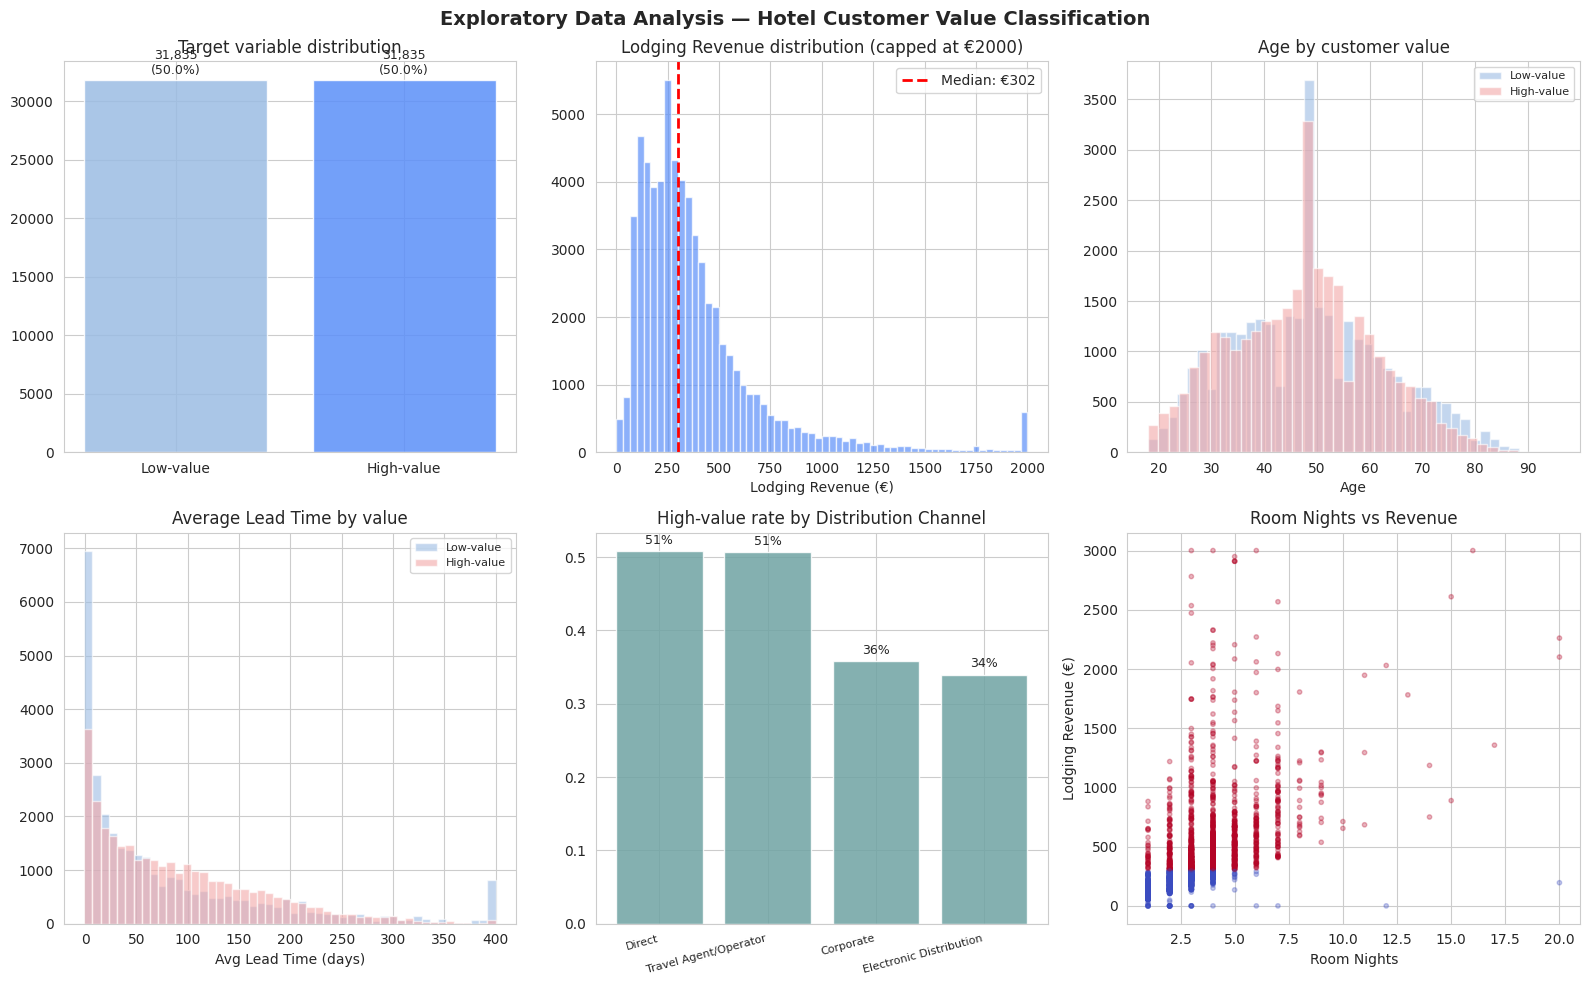

Saved: eda_customer_value.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — Hotel Customer Value Classification', fontsize=14, fontweight='bold')

# 1. Target distribution
counts = df['is_high_value'].value_counts().sort_index()
axes[0,0].bar(['Low-value', 'High-value'], counts, color=['#9BBCE3', '#5B8FF9'], alpha=0.85, edgecolor='white')
axes[0,0].set_title('Target variable distribution')
for i, v in enumerate(counts):
    axes[0,0].text(i, v+500, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=9)

# 2. Revenue distribution
axes[0,1].hist(df['LodgingRevenue'].clip(upper=2000), bins=60, color='#5B8FF9', alpha=0.7, edgecolor='white')
axes[0,1].axvline(revenue_median, color='red', ls='--', lw=2, label=f'Median: €{revenue_median:.0f}')
axes[0,1].set_title('Lodging Revenue distribution (capped at €2000)')
axes[0,1].set_xlabel('Lodging Revenue (€)')
axes[0,1].legend()

# 3. Age by value group
df[df.is_high_value==0]['Age'].hist(ax=axes[0,2], bins=40, alpha=0.6, color='#9BBCE3', label='Low-value')
df[df.is_high_value==1]['Age'].hist(ax=axes[0,2], bins=40, alpha=0.6, color='#F2A7A7', label='High-value')
axes[0,2].set_title('Age by customer value')
axes[0,2].set_xlabel('Age')
axes[0,2].legend(fontsize=8)

# 4. Average Lead Time by value
for val, color, label in [(0, '#9BBCE3', 'Low-value'), (1, '#F2A7A7', 'High-value')]:
    subset = df[df.is_high_value == val]['AverageLeadTime'].clip(upper=400)
    axes[1,0].hist(subset, bins=50, alpha=0.6, color=color, label=label)
axes[1,0].set_title('Average Lead Time by value')
axes[1,0].set_xlabel('Avg Lead Time (days)')
axes[1,0].legend(fontsize=8)

# 5. Distribution Channel
dc = df.groupby('DistributionChannel')['is_high_value'].mean().sort_values(ascending=False)
axes[1,1].bar(dc.index, dc.values, color='#6FA3A3', alpha=0.85, edgecolor='white')
axes[1,1].set_title('High-value rate by Distribution Channel')
axes[1,1].set_xticklabels(dc.index, rotation=15, ha='right', fontsize=8)
for i, (k, v) in enumerate(dc.items()):
    axes[1,1].text(i, v+0.01, f'{v:.0%}', ha='center', fontsize=9)

# 6. Room Nights vs Revenue
sample = df.sample(min(3000, len(df)), random_state=RANDOM_STATE)
axes[1,2].scatter(sample['RoomNights'].clip(upper=20), sample['LodgingRevenue'].clip(upper=3000),
                  c=sample['is_high_value'], cmap='coolwarm', alpha=0.3, s=10)
axes[1,2].set_title('Room Nights vs Revenue')
axes[1,2].set_xlabel('Room Nights')
axes[1,2].set_ylabel('Lodging Revenue (€)')

plt.tight_layout()
plt.savefig('eda_customer_value.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_customer_value.png')


## 4. Feature Engineering

### Leakage prevention

This is critical: since our target is derived from `LodgingRevenue`, we must exclude features that **directly determine** or are **trivially correlated** with lodging revenue:

| Excluded feature | Reason |
|---|---|
| `LodgingRevenue` | Target is derived from this — direct leakage |
| `OtherRevenue` | Spending variable — highly correlated with lodging spend |
| `PersonsNights` | Directly determines revenue (nights × persons × rate) |
| `RoomNights` | Directly determines revenue (nights × rate) |

### Retained features
We retain features that describe **who the customer is** and **how they interact with the hotel**, not how much they spent:
- **Demographics**: Age, Nationality
- **Booking behavior**: AverageLeadTime, BookingsCheckedIn, BookingsCanceled, BookingsNoShowed
- **Tenure/recency**: DaysSinceCreation, DaysSinceFirstStay, DaysSinceLastStay
- **Channel**: DistributionChannel, MarketSegment
- **Preferences**: All 13 SR* special request flags


In [6]:
TARGET = 'is_high_value'

# ── Exclude leakage features ──
LEAKAGE_COLS = ['LodgingRevenue', 'OtherRevenue', 'PersonsNights', 'RoomNights']
df_model = df.drop(columns=LEAKAGE_COLS + [TARGET])

# ── Feature engineering ──

# 1. Nationality: too many categories (188) — reduce to top 10 + 'Other'
top_nations = df_model['Nationality'].value_counts().head(10).index.tolist()
df_model['Nationality'] = df_model['Nationality'].apply(lambda x: x if x in top_nations else 'Other')
print(f'Nationality: reduced to {df_model["Nationality"].nunique()} categories (top 10 + Other)')

# 2. Total special requests (sum of all SR flags)
sr_cols = [c for c in df_model.columns if c.startswith('SR')]
df_model['total_special_requests'] = df_model[sr_cols].sum(axis=1)
print(f'Created total_special_requests from {len(sr_cols)} SR flags')

# 3. Has canceled before (binary)
df_model['has_canceled'] = (df_model['BookingsCanceled'] > 0).astype(int)

# 4. Has no-showed before (binary)
df_model['has_noshowed'] = (df_model['BookingsNoShowed'] > 0).astype(int)

# 5. Is repeat customer
df_model['is_repeat'] = (df_model['BookingsCheckedIn'] > 1).astype(int)

# 6. Customer tenure (days)
df_model['tenure_days'] = df_model['DaysSinceFirstStay'] - df_model['DaysSinceLastStay']
df_model['tenure_days'] = df_model['tenure_days'].clip(lower=0)

# 7. Log-transform skewed features
for col in ['AverageLeadTime', 'DaysSinceCreation']:
    df_model[f'{col}_log'] = np.log1p(df_model[col].clip(lower=0))

new_feats = ['total_special_requests', 'has_canceled', 'has_noshowed',
             'is_repeat', 'tenure_days', 'AverageLeadTime_log', 'DaysSinceCreation_log']
print(f'\nEngineered features ({len(new_feats)}): {new_feats}')

y = df[TARGET]
X = df_model.copy()

print(f'\nFinal feature matrix: {X.shape}')
print(f'Target: {y.shape}')


Nationality: reduced to 11 categories (top 10 + Other)
Created total_special_requests from 13 SR flags

Engineered features (7): ['total_special_requests', 'has_canceled', 'has_noshowed', 'is_repeat', 'tenure_days', 'AverageLeadTime_log', 'DaysSinceCreation_log']

Final feature matrix: (63670, 31)
Target: (63670,)


## 5. Data Splitting

**Best practices applied:**
- **Stratified 80/20 split** — preserves the ~50% class ratio in both sets.
- **Test set sealed** — used only for final evaluation.
- **Pipeline-based preprocessing** — encoders fit only on training data to prevent leakage.


In [7]:
# ── Identify column types ──
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numerical   ({len(num_cols)}): {num_cols[:8]}...  [{len(num_cols)} total]')

# ── Preprocessing pipelines ──
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# ── Stratified 80/20 split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'\n{"="*55}')
print('DATA SPLIT SUMMARY')
print('='*55)
print(f'Train : {len(X_train):,} samples | high-value rate: {y_train.mean():.2%}')
print(f'Test  : {len(X_test):,}  samples | high-value rate: {y_test.mean():.2%}')
print('Stratification confirmed: class ratio preserved.')


Categorical (3): ['Nationality', 'DistributionChannel', 'MarketSegment']
Numerical   (28): ['Age', 'DaysSinceCreation', 'AverageLeadTime', 'BookingsCanceled', 'BookingsNoShowed', 'BookingsCheckedIn', 'DaysSinceLastStay', 'DaysSinceFirstStay']...  [28 total]

DATA SPLIT SUMMARY
Train : 50,936 samples | high-value rate: 50.00%
Test  : 12,734  samples | high-value rate: 50.00%
Stratification confirmed: class ratio preserved.


## 6. Model Training

### Metric justification

| Metric | Why it matters for customer value classification |
|--------|--------------------------------------------------|
| **Accuracy** | Overall correctness. Meaningful here because classes are balanced (~50/50). |
| **Precision** | Of customers predicted as high-value, how many truly are? Low precision → wasted retention resources on low-value customers. |
| **Recall** | Of actual high-value customers, how many did we identify? Low recall → missed high-value customers who may churn. |
| **F1-Score** | Harmonic mean of precision and recall. **Primary metric** for balanced evaluation. |
| **ROC-AUC** | Threshold-independent discrimination ability. **Primary metric.** |

### Models trained
1. **Majority class** — trivial baseline
2. **Logistic Regression** — linear baseline (benefits from StandardScaler)
3. **Random Forest** — ensemble baseline
4. **XGBoost** — main model (consistent with Dataset 1 analysis)


In [8]:
def make_pipe(estimator):
    return Pipeline(steps=[('pre', preprocessor), ('clf', estimator)])

def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    pred  = pipe.predict(X_te)
    proba = pipe.predict_proba(X_te)[:,1] if hasattr(pipe.named_steps['clf'], 'predict_proba') else None
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall'   : recall_score(y_te, pred, zero_division=0),
        'F1'       : f1_score(y_te, pred, zero_division=0),
        'AUC'      : roc_auc_score(y_te, proba) if proba is not None else None,
        '_pipe'    : pipe,
        '_pred'    : pred,
        '_proba'   : proba,
    }

results = []

# 1. Majority class
print('Training Majority Class Baseline...')
dummy = make_pipe(DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
results.append(evaluate('Majority Class', dummy, X_train, y_train, X_test, y_test))

# 2. Logistic Regression
print('Training Logistic Regression...')
lr_pipe = make_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
results.append(evaluate('Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test))

# 3. Random Forest
print('Training Random Forest...')
rf_pipe = make_pipe(RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                           n_jobs=-1, random_state=RANDOM_STATE))
results.append(evaluate('Random Forest', rf_pipe, X_train, y_train, X_test, y_test))

# 4. XGBoost
print('Training XGBoost...')
xgb_pipe = make_pipe(XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
))
results.append(evaluate('XGBoost', xgb_pipe, X_train, y_train, X_test, y_test))

print('\nAll models trained.')


Training Majority Class Baseline...
Training Logistic Regression...
Training Random Forest...
Training XGBoost...

All models trained.


## 7. Model Evaluation & Metrics

In [9]:
res_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])
res_df = res_df.set_index('Model')

print('='*75)
print('MODEL COMPARISON (test set)')
print('='*75)
display_df = res_df.copy()
for col in display_df.columns:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else 'N/A')
print(display_df.to_string())
print()
print('Primary metrics: AUC and F1-Score.')


MODEL COMPARISON (test set)
                    Accuracy Precision  Recall      F1     AUC
Model                                                         
Majority Class        0.5000    0.0000  0.0000  0.0000  0.5000
Logistic Regression   0.7024    0.6898  0.7355  0.7119  0.7779
Random Forest         0.7672    0.7600  0.7812  0.7704  0.8549
XGBoost               0.7411    0.7182  0.7936  0.7540  0.8223

Primary metrics: AUC and F1-Score.


In [10]:
# Detailed report for XGBoost
xgb_result = next(r for r in results if 'XGBoost' in r['Model'])
print('='*55)
print('XGBoost — CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, xgb_result['_pred'],
                            target_names=['Low-value', 'High-value']))


XGBoost — CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Low-value       0.77      0.69      0.73      6367
  High-value       0.72      0.79      0.75      6367

    accuracy                           0.74     12734
   macro avg       0.74      0.74      0.74     12734
weighted avg       0.74      0.74      0.74     12734



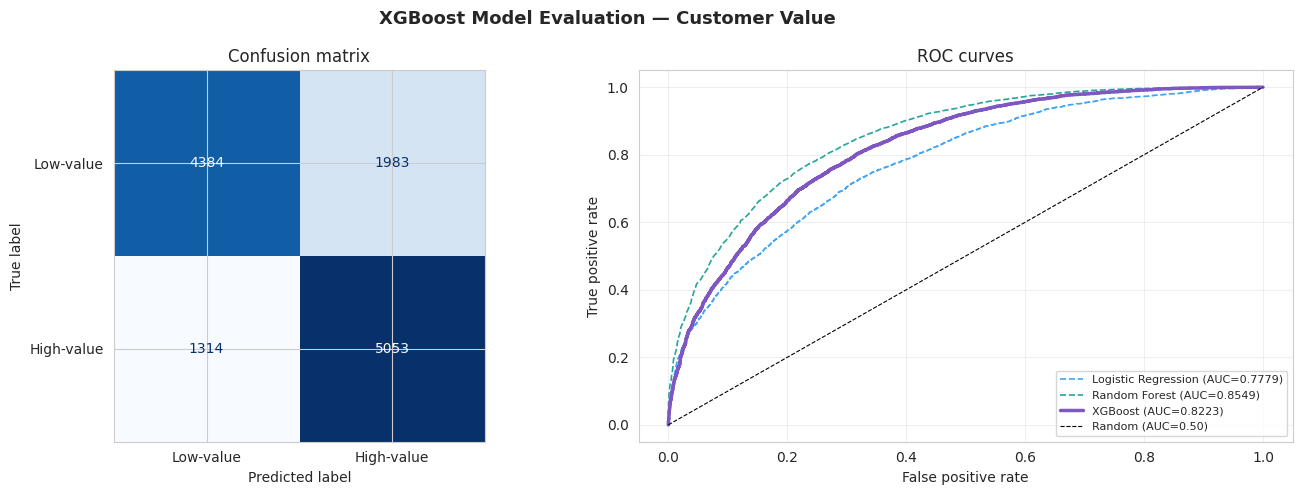

Saved: evaluation_customer_value.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Model Evaluation — Customer Value', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, xgb_result['_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Low-value', 'High-value']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix')

# ROC curves
colors = ['#42A5F5', '#26A69A', '#7E57C2']
ci = 0
for r in results:
    if r['_proba'] is not None and r['Model'] != 'Majority Class':
        fpr, tpr, _ = roc_curve(y_test, r['_proba'])
        auc = r['AUC']
        lw = 2.5 if 'XGBoost' in r['Model'] else 1.2
        ls = '-' if 'XGBoost' in r['Model'] else '--'
        axes[1].plot(fpr, tpr, lw=lw, ls=ls, color=colors[ci],
                    label=f"{r['Model']} (AUC={auc:.4f})")
        ci += 1
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Random (AUC=0.50)')
axes[1].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curves')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_customer_value.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_customer_value.png')


## 8. Cross-Validation

5-fold stratified cross-validation on the training set to confirm model stability.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': make_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
    'Random Forest':       make_pipe(RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                                             n_jobs=-1, random_state=RANDOM_STATE)),
    'XGBoost':             make_pipe(XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                                   subsample=0.8, colsample_bytree=0.8,
                                                   use_label_encoder=False, eval_metric='logloss',
                                                   random_state=RANDOM_STATE, n_jobs=-1))
}

print('='*60)
print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS (ROC-AUC)')
print('='*60)
cv_summary = {}
for name, pipe in cv_models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_summary[name] = scores
    print(f'\n{name}')
    for i, s in enumerate(scores, 1):
        print(f'  Fold {i}: {s:.4f}')
    print(f'  Mean ± Std: {scores.mean():.4f} ± {scores.std():.4f}')


5-FOLD STRATIFIED CROSS-VALIDATION RESULTS (ROC-AUC)

Logistic Regression
  Fold 1: 0.7708
  Fold 2: 0.7554
  Fold 3: 0.7643
  Fold 4: 0.7674
  Fold 5: 0.7733
  Mean ± Std: 0.7662 ± 0.0062

Random Forest
  Fold 1: 0.8526
  Fold 2: 0.8444
  Fold 3: 0.8494
  Fold 4: 0.8505
  Fold 5: 0.8526
  Mean ± Std: 0.8499 ± 0.0030

XGBoost
  Fold 1: 0.8228
  Fold 2: 0.8156
  Fold 3: 0.8200
  Fold 4: 0.8122
  Fold 5: 0.8238
  Mean ± Std: 0.8189 ± 0.0044


## 9. Feature Importance

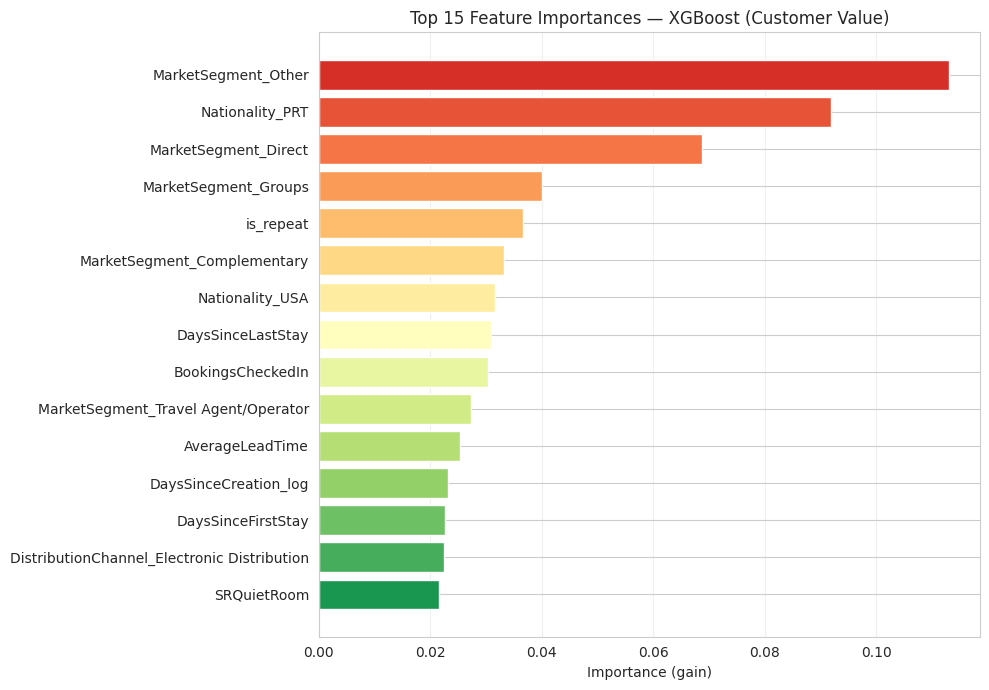

Top 10 features:
                            feature  importance
                MarketSegment_Other    0.112972
                    Nationality_PRT    0.091834
               MarketSegment_Direct    0.068686
               MarketSegment_Groups    0.040070
                          is_repeat    0.036630
        MarketSegment_Complementary    0.033151
                    Nationality_USA    0.031687
                  DaysSinceLastStay    0.030832
                  BookingsCheckedIn    0.030271
MarketSegment_Travel Agent/Operator    0.027228

Saved: feature_importance_customer.png


In [13]:
# Get feature names after preprocessing
xgb_fitted = xgb_result['_pipe']
ohe_features = (xgb_fitted.named_steps['pre']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(cat_cols).tolist())
all_features = num_cols + ohe_features

imp_df = pd.DataFrame({
    'feature': all_features,
    'importance': xgb_fitted.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(imp_df)))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=palette)
ax.set(xlabel='Importance (gain)', title='Top 15 Feature Importances — XGBoost (Customer Value)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_customer.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(imp_df.head(10)[['feature', 'importance']].to_string(index=False))
print('\nSaved: feature_importance_customer.png')


## 10. Final Results Summary & Saved Assets

In [14]:
# Final comparison
final_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results]).set_index('Model')
print('='*75)
print('FINAL MODEL COMPARISON (test set)')
print('='*75)
print(final_df.applymap(lambda x: f'{float(x):.4f}' if x is not None else 'N/A').to_string())

xgb_cv = cv_summary['XGBoost']
print(f'\nXGBoost 5-fold CV AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')


FINAL MODEL COMPARISON (test set)
                    Accuracy Precision  Recall      F1     AUC
Model                                                         
Majority Class        0.5000    0.0000  0.0000  0.0000  0.5000
Logistic Regression   0.7024    0.6898  0.7355  0.7119  0.7779
Random Forest         0.7672    0.7600  0.7812  0.7704  0.8549
XGBoost               0.7411    0.7182  0.7936  0.7540  0.8223

XGBoost 5-fold CV AUC: 0.8189 ± 0.0044


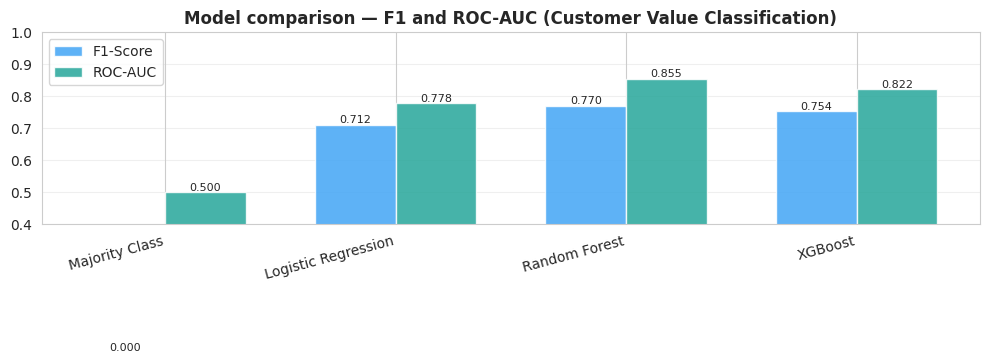

Saved: model_comparison_customer.png


In [15]:
# Bar chart
plot_df = final_df[final_df['AUC'].notna()][['F1','AUC']].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
b1 = ax.bar(x - w/2, plot_df['F1'],  w, label='F1-Score', color='#42A5F5', alpha=0.85)
b2 = ax.bar(x + w/2, plot_df['AUC'], w, label='ROC-AUC',  color='#26A69A', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.set_ylim(0.4, 1.0)
ax.set_title('Model comparison — F1 and ROC-AUC (Customer Value Classification)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison_customer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_customer.png')


In [ ]:
# Save assets
with open('xgb_customer_value_model.pkl', 'wb') as f:
    pickle.dump(xgb_result['_pipe'], f)
with open('customer_feature_list.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print('='*55)
print('SAVED ASSETS')
print('='*55)
assets = [
    ('xgb_customer_value_model.pkl',    'Trained XGBoost pipeline (preprocessor + model)'),
    ('customer_feature_list.pkl',       'Input feature names'),
    ('eda_customer_value.png',          'EDA visualisations'),
    ('evaluation_customer_value.png',   'Confusion matrix + ROC curve'),
    ('feature_importance_customer.png', 'XGBoost feature importance'),
    ('model_comparison_customer.png',   'F1 / AUC bar chart'),
]
for fname, desc in assets:
    print(f'  {fname:<40} {desc}')


---

## Code Organisation & Runbook

### Repository structure
```
project/
├── hotel_cancellation_prediction_v2.ipynb   ← Dataset 1 notebook (booking-level)
├── hotel_customer_value_classification.ipynb ← Dataset 2 notebook (customer-level) — this file
├── hotel_bookings.csv                        ← Dataset 1
├── HotelCustomersDataset.xlsx                ← Dataset 2
├── xgb_best_model.pkl                        ← Dataset 1 saved pipeline
├── xgb_customer_value_model.pkl              ← Dataset 2 saved pipeline
└── outputs/
    ├── eda_customer_value.png
    ├── evaluation_customer_value.png
    ├── feature_importance_customer.png
    └── model_comparison_customer.png
```

### How to reproduce

**Step 1 — Get the data**  
Download `HotelCustomersDataset.xlsx` from the paper's supplementary files:  
http://dx.doi.org/10.17632/j83f5fsh6c.1

**Step 2 — Open in Colab / Jupyter**  
Upload this notebook and the dataset.

**Step 3 — Update the data path** (Cell — Load data):  
```python
df_raw = pd.read_excel('HotelCustomersDataset.xlsx')
```

**Step 4 — Run all cells**  
Expected runtime: ~5–10 min.

### Reproducibility notes
- `RANDOM_STATE = 42` used in all stochastic operations (same as Dataset 1 notebook)
- All splits use `stratify=y`
- Preprocessing pipeline fit only on training data
- Test set never used during CV
